In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib. pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.multitest as multi
import scipy.stats as scp
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PHẦN 1: FUNCTIONS (giữ nguyên)
# ============================================================================

def response_rate_logit(x, y):
    """Logistic regression function"""
    log_reg = sm.Logit(y, sm.add_constant(x)).fit(method='lbfgs', maxiter=99999, disp=0)
    return log_reg. pvalues, log_reg.params


def calculate_logistic_regression(df_merge, feature_cols, response_col='BOR_Bin'):
    """Tính logistic regression cho tất cả features"""
    log_reg = []
    
    for feature in feature_cols:
        data = df_merge[[feature, response_col]].dropna()
        
        if len(data) < 10:
            print(f"⚠ Warning: {feature} has only {len(data)} samples, skipping...")
            continue
        
        X = data[[feature]]
        y = data[response_col]
        
        try:
            p, param = response_rate_logit(X, y)
            log_reg.append([feature, p[1], param[1], len(data)])
        except Exception as e: 
            print(f"⚠ Warning: {feature} failed - {str(e)}")
            continue
    
    log_reg_df = pd.DataFrame(log_reg, columns=['Feature', 'p_value', 'coeff', 'N']).set_index('Feature')
    log_reg_df['q_value'] = multi.multipletests(log_reg_df['p_value'], method='fdr_bh')[1]
    log_reg_df['Signed_log10_q'] = -np.log10(log_reg_df['q_value']) * np.sign(log_reg_df['coeff'])
    log_reg_df['hue'] = np.sign(log_reg_df['coeff'])
    
    return log_reg_df


def plot_barplot_horizontal(df_plot, title, figsize=(6, 8), xlim=(-1.5, 1.5), 
                           output_file=None, custom_labels=None):
    """Vẽ horizontal barplot với significance lines"""
    plt.figure(figsize=figsize)
    
    labels = df_plot.index. tolist()
    if custom_labels:
        labels = [custom_labels. get(x, x) for x in labels]
    
    h = sns.barplot(
        y=labels,
        x=df_plot['Signed_log10_q'], 
        orient='h',
        hue=df_plot['hue'], 
        dodge=False,
        palette={1.0: '#1f77b4', -1.0: '#ff7f0e'}
    )
    
    ax = plt.gca()
    ymin, ymax = ax.get_ylim()
    
    plt.vlines(x=0, ymin=ymin, ymax=ymax, colors='k', linewidth=1.5)
    ax.axvline(linewidth=1.5, x=-np.log10(0.1), linestyle='-', c='r', alpha=0.7)
    ax.axvline(linewidth=1.5, x=-np.log10(0.25), linestyle='--', c='purple', alpha=0.7)
    ax.axvline(linewidth=1.5, x=np.log10(0.1), linestyle='-', c='r', alpha=0.7)
    ax.axvline(linewidth=1.5, x=np.log10(0.25), linestyle='--', c='purple', alpha=0.7)
    
    plt.ylabel(None)
    plt.setp(ax.get_yticklabels(), font='Arial', fontsize=14, weight='bold')
    plt.setp(ax.get_xticklabels(), font='Arial', fontsize=12, weight='bold')
    plt.xlim(xlim)
    plt.ylim(len(df_plot) - 0.5, -0.5)
    
    plt.xlabel('$\\mathregular{Signed\\hspace{0.5}log_{10}(q\\mathrm{-}value)}$', 
               weight='bold', fontsize=16, labelpad=10)
    plt.title(title, fontsize=18, weight='bold', pad=15)
    
    if h.legend_:
        h.legend_. remove()
    
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='r', lw=1.5, linestyle='-'),
        Line2D([0], [0], color='purple', lw=1.5, linestyle='--')
    ]
    ax.legend(custom_lines, ['q = 0.1', 'q = 0.25'], 
             loc='lower right', fontsize=10, frameon=True)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"✓ Saved:  {output_file}")
    
    plt.show()
    
    return ax


def zscore_normalize(df, feature_cols):
    """Apply z-score normalization to features"""
    df_norm = df.copy()
    
    for col in feature_cols:
        valid_data = df_norm[col].dropna()
        mean_val = valid_data.mean()
        std_val = valid_data.std()
        df_norm[col + '_norm'] = (df_norm[col] - mean_val) / std_val
        
    return df_norm


In [47]:
# ============================================================================
# PHẦN 2: LOAD VÀ XỬ LÝ DỮ LIỆU
# ============================================================================

print("=" * 70)
print("LOADING DATA...")
print("=" * 70)

# Đọc 3 dataframe
clinical = pd.read_csv('../../Data/original_data.csv')  # Columns: Patient_ID, BOR
clinical = clinical[['Patient_ID','Harmonized_Confirmed_BOR_3_Cat']]
zi_scores = pd.read_csv('Signature_analysis/ZI_original.csv')      # Columns: Patient_ID, hMø1_ZI, hMø4_ZI, ... 
# sf_scores = pd.read_csv('Signature_analysis/SF_original.csv')      # Columns: Patient_ID, B-cells_SF, Cytotoxic cells_SF, ...

source_data_path = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/ExperimentNSCLC/LungCancer_ICB/Source Data/"
source_data_path_rna = source_data_path + 'RNA/'
sf_scores = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_SF_v1.txt',sep='\t')
sf_scores = sf_scores.rename(columns={"Harmonized_SU2C_RNA_Tumor_Sample_ID_v2": "Patient_ID"})

print(f"✓ Clinical data: {clinical.shape}")
print(f"✓ ZI scores (Myeloid): {zi_scores.shape}")
print(f"✓ SF scores (Immune): {sf_scores.shape}")




# ===== XỬ LÝ BOR =====
print("\n" + "=" * 70)
print("PROCESSING BOR COLUMN...")
print("=" * 70)

clinical['BOR_Bin'] = clinical['Harmonized_Confirmed_BOR_3_Cat'].map({
    'PR/CR': 1, 'CR/PR': 1, 'PR': 1, 'CR': 1,
    'SD': 0, 'PD': 0
})

print("\nBOR distribution:")
print(clinical['Harmonized_Confirmed_BOR_3_Cat']. value_counts())
print(f"\nResponse rate: {clinical['BOR_Bin'].mean() * 100:.1f}%")

if clinical['BOR_Bin'].isna().any():
    print(f"\n⚠ WARNING: {clinical['BOR_Bin']. isna().sum()} missing BOR_Bin values")


# ===== MERGE =====
print("\n" + "=" * 70)
print("MERGING DATA...")
print("=" * 70)

df_merge = clinical.merge(sf_scores, on='Patient_ID', how='inner')
df_merge = df_merge.merge(zi_scores, on='Patient_ID', how='inner')

print(f"✓ Merged data shape: {df_merge.shape}")
print(f"✓ Final sample size: {len(df_merge)}")

# Lấy danh sách features (đã không có _SF và _ZI)
sf_features = [col for col in sf_scores.columns if col != 'Patient_ID']
zi_features = [col for col in zi_scores.columns if col != 'Patient_ID']

print(f"✓ SF features: {len(sf_features)}")
print(f"✓ ZI features: {len(zi_features)}")

LOADING DATA...
✓ Clinical data: (152, 2)
✓ ZI scores (Myeloid): (152, 19)
✓ SF scores (Immune): (152, 12)

PROCESSING BOR COLUMN...

BOR distribution:
Harmonized_Confirmed_BOR_3_Cat
CR/PR    60
PD       50
SD       42
Name: count, dtype: int64

Response rate: 39.5%

MERGING DATA...
✓ Merged data shape: (152, 32)
✓ Final sample size: 152
✓ SF features: 11
✓ ZI features: 18


In [48]:
# ============================================================================
# PHẦN 3: Z-SCORE NORMALIZATION
# ============================================================================

print("\n" + "=" * 70)
print("APPLYING Z-SCORE NORMALIZATION...")
print("=" * 70)

df_merge = zscore_normalize(df_merge, sf_features + zi_features)

sf_features_norm = [col + '_norm' for col in sf_features]
zi_features_norm = [col + '_norm' for col in zi_features]

print(f"✓ Normalized {len(sf_features)} SF features")
print(f"✓ Normalized {len(zi_features)} ZI features")

# Kiểm tra normalization
print("\n=== Normalization Check (first 3 features) ===")
for col in sf_features[:3]: 
    col_norm = col + '_norm'
    print(f"\n{col}:")
    print(f"  Original: mean={df_merge[col].mean():.3f}, std={df_merge[col].std():.3f}")
    print(f"  Normalized: mean={df_merge[col_norm].mean():.3f}, std={df_merge[col_norm].std():.3f}")


APPLYING Z-SCORE NORMALIZATION...
✓ Normalized 11 SF features
✓ Normalized 18 ZI features

=== Normalization Check (first 3 features) ===

B-cells:
  Original: mean=-0.005, std=1.001
  Normalized: mean=0.000, std=1.000

Cytotoxic cells:
  Original: mean=0.001, std=1.003
  Normalized: mean=-0.000, std=1.000

DC:
  Original: mean=-0.007, std=1.000
  Normalized: mean=0.000, std=1.000


In [49]:
# ============================================================================
# PHẦN 4: TÍNH LOGISTIC REGRESSION
# ============================================================================

print("\n" + "=" * 70)
print("CALCULATING LOGISTIC REGRESSION...")
print("=" * 70)

# SF (Immune Cell Subsets)
print("\n[1/2] Processing Immune Cell Subsets...")
sf_results = calculate_logistic_regression(df_merge, sf_features_norm)
sf_results_sorted = sf_results.sort_values('Signed_log10_q', ascending=False)

print(f"✓ Completed {len(sf_results)} features")
print(f"  - Significant (q < 0.1): {(sf_results['q_value'] < 0.1).sum()}")
print(f"  - Near-significant (q < 0.25): {(sf_results['q_value'] < 0.25).sum()}")

# ZI (Myeloid Subsets)
print("\n[2/2] Processing Myeloid Subsets...")
zi_results = calculate_logistic_regression(df_merge, zi_features_norm)

# ===== SORT THEO THỨ TỰ (ĐÃ BỎ _ZI) =====
myeloid_order = ['hMono2_norm', 'hMono1_norm', 'hMono3_norm', 
                 'hMø1_norm', 'hMø9_norm', 'hMø6_norm', 'hMø4_norm', 
                 'hMø5_norm', 'hMø8_norm', 'hMø7_norm',
                 'hN2_norm', 'hN1_norm', 'hN5_norm', 'hN3_norm',
                 'hDC2_norm', 'hDC1_norm', 'hpDC_norm', 'hDC3_norm']

available_myeloid = [f for f in myeloid_order if f in zi_results.index]
zi_results_sorted = zi_results.loc[available_myeloid]

print(f"✓ Completed {len(zi_results)} features")
print(f"  - Significant (q < 0.1): {(zi_results['q_value'] < 0.1).sum()}")
print(f"  - Near-significant (q < 0.25): {(zi_results['q_value'] < 0.25).sum()}")



CALCULATING LOGISTIC REGRESSION...

[1/2] Processing Immune Cell Subsets...
✓ Completed 11 features
  - Significant (q < 0.1): 0
  - Near-significant (q < 0.25): 6

[2/2] Processing Myeloid Subsets...
✓ Completed 18 features
  - Significant (q < 0.1): 0
  - Near-significant (q < 0.25): 0


In [51]:
sf_results_sorted

,p_value,coeff,N,q_value,Signed_log10_q,hue
Feature,,,,,,
Cytotoxic cells_norm,0.098144,0.283623,152,0.179931,0.744894,1.0
Exhausted/HS CD8_norm,0.094591,0.292752,152,0.179931,0.744894,1.0
Exhausted CD8_norm,0.020067,0.410513,152,0.179931,0.744894,1.0
Treg_norm,0.034240,0.373921,152,0.179931,0.744894,1.0
Lymphocytes exhausted/cell cycle_norm,0.086152,0.305204,152,0.179931,0.744894,1.0
Lymphocytes_norm,0.090008,0.293822,152,0.179931,0.744894,1.0
B-cells_norm,0.171321,0.229511,152,0.258903,0.586863,1.0
Memory T cells_norm,0.351978,0.155652,152,0.387176,0.412092,1.0
Plasma_norm,0.820877,0.037802,152,0.820877,0.085722,1.0


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.



PLOTTING...

[1/2] Plotting Immune Cell Subsets...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

✓ Saved:  Fig_Immune_Cell_Subsets_Normalized.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


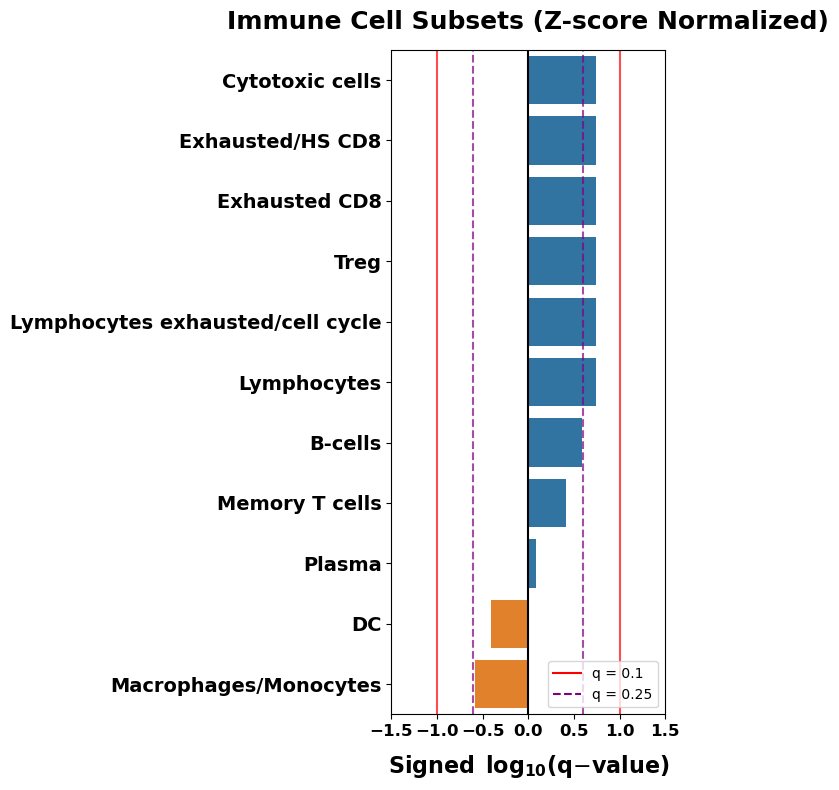

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


[2/2] Plotting Myeloid Subsets...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

✓ Saved:  Fig_Myeloid_Subsets_Normalized.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

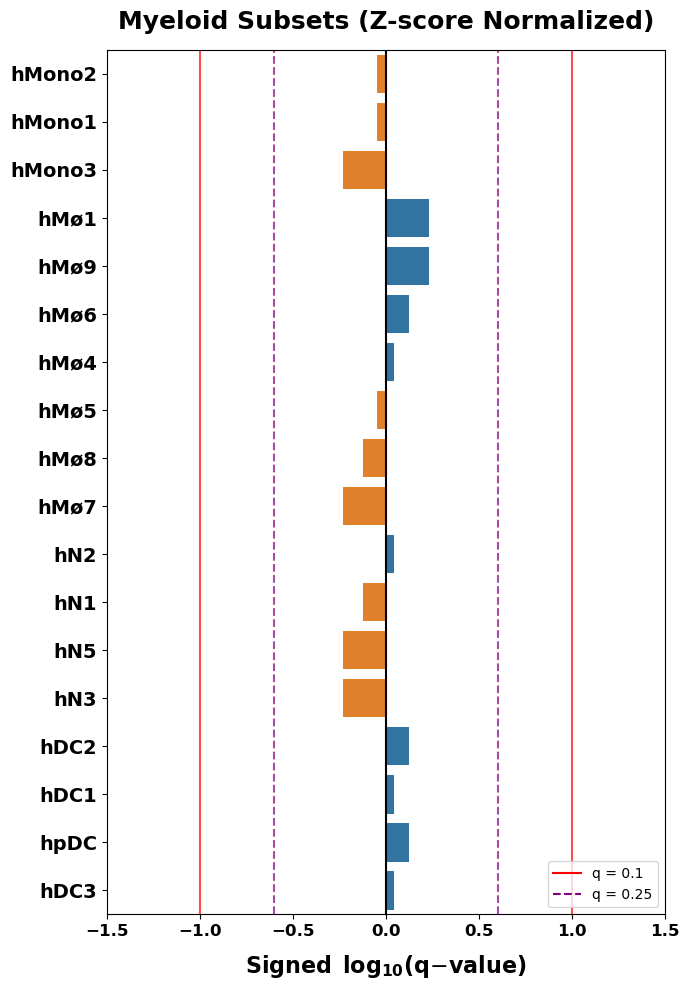

<Axes: title={'center': 'Myeloid Subsets (Z-score Normalized)'}, xlabel='$\\mathregular{Signed\\hspace{0.5}log_{10}(q\\mathrm{-}value)}$'>

In [45]:
# ============================================================================
# PHẦN 5: VẼ BIỂU ĐỒ
# ============================================================================

print("\n" + "=" * 70)
print("PLOTTING...")
print("=" * 70)

# Immune Cell Subsets
print("\n[1/2] Plotting Immune Cell Subsets...")
sf_labels = {col: col.replace('_norm', '') for col in sf_results_sorted.index}

plot_barplot_horizontal(
    sf_results_sorted,
    title='Immune Cell Subsets (Z-score Normalized)',
    figsize=(7, 8),
    xlim=(-1.5, 1.5),
    output_file='Fig_Immune_Cell_Subsets_Normalized.png',
    custom_labels=sf_labels
)

# Myeloid Subsets
print("\n[2/2] Plotting Myeloid Subsets...")
zi_labels = {col: col.replace('_norm', '') for col in zi_results_sorted. index}

plot_barplot_horizontal(
    zi_results_sorted,
    title='Myeloid Subsets (Z-score Normalized)',
    figsize=(7, 10),
    xlim=(-1.5, 1.5),
    output_file='Fig_Myeloid_Subsets_Normalized.png',
    custom_labels=zi_labels
)

In [11]:
print("\n" + "=" * 60)
print("CALCULATING LOGISTIC REGRESSION...")
print("=" * 60)

# --- 3.1. SF (Immune Cell Subsets) ---
print("\n[1/2] Processing Immune Cell Subsets...")
sf_results = calculate_logistic_regression(df_merge, sf_features)
sf_results_sorted = sf_results.sort_values('Signed_log10_q', ascending=False)

print(f"✓ Completed {len(sf_results)} features")
print(f"  - Significant (q < 0.1): {(sf_results['q_value'] < 0.1).sum()}")
print(f"  - Near-significant (q < 0.25): {(sf_results['q_value'] < 0.25).sum()}")

# --- 3.2. ZI (Myeloid Subsets) ---
print("\n[2/2] Processing Myeloid Subsets...")
zi_results = calculate_logistic_regression(df_merge, zi_features)

# Sort theo thứ tự trong notebook (nếu có đủ các features này)
myeloid_order = ['hMono2', 'hMono1', 'hMono3', 
                 'hMø1', 'hMø9', 'hMø6', 'hMø4', 'hMø5', 'hMø8', 'hMø7',
                 'hN2', 'hN1', 'hN5', 'hN3',
                 'hDC2', 'hDC1', 'hpDC', 'hDC3']

# Lấy những features có trong data
available_myeloid = [f for f in myeloid_order if f in zi_results.index]
zi_results_sorted = zi_results.loc[available_myeloid]

print(f"✓ Completed {len(zi_results)} features")
print(f"  - Significant (q < 0.1): {(zi_results['q_value'] < 0.1).sum()}")
print(f"  - Near-significant (q < 0.25): {(zi_results['q_value'] < 0.25).sum()}")


CALCULATING LOGISTIC REGRESSION...

[1/2] Processing Immune Cell Subsets...
✓ Completed 11 features
  - Significant (q < 0.1): 0
  - Near-significant (q < 0.25): 2

[2/2] Processing Myeloid Subsets...
✓ Completed 18 features
  - Significant (q < 0.1): 0
  - Near-significant (q < 0.25): 0



PLOTTING...

[1/2] Plotting Immune Cell Subsets...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

✓ Saved:  Fig_Immune_Cell_Subsets.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


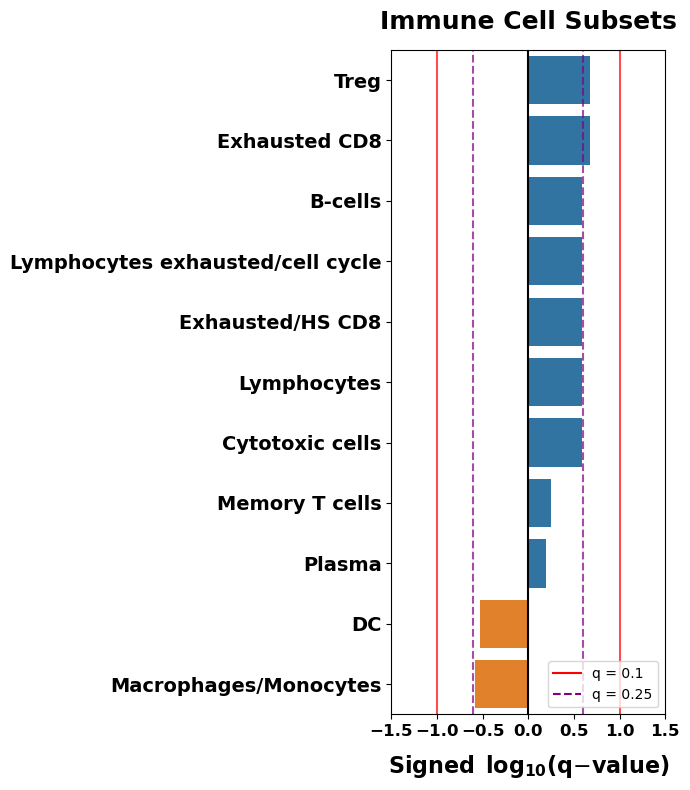

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


[2/2] Plotting Myeloid Subsets...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

✓ Saved:  Fig_Myeloid_Subsets.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

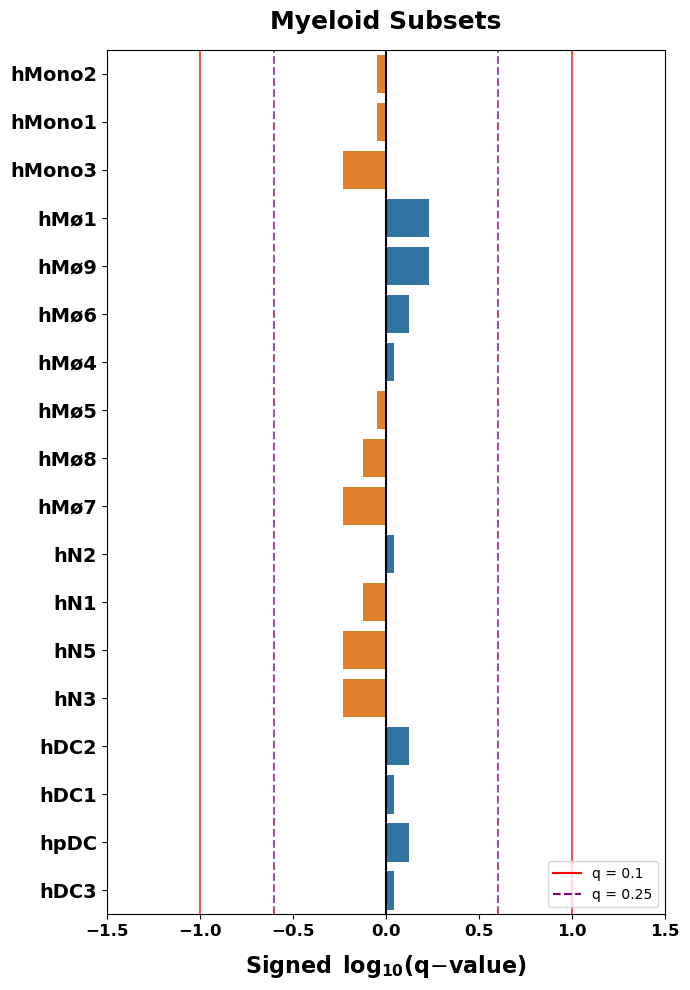

<Axes: title={'center': 'Myeloid Subsets'}, xlabel='$\\mathregular{Signed\\hspace{0.5}log_{10}(q\\mathrm{-}value)}$'>

In [12]:
print("\n" + "=" * 60)
print("PLOTTING...")
print("=" * 60)

# --- 4.1. Immune Cell Subsets ---
print("\n[1/2] Plotting Immune Cell Subsets...")

# Custom labels (bỏ _SF suffix)
sf_labels = {col:  col.replace('_SF', '') for col in sf_results_sorted.index}

plot_barplot_horizontal(
    sf_results_sorted,
    title='Immune Cell Subsets',
    figsize=(7, 8),
    xlim=(-1.5, 1.5),
    output_file='Fig_Immune_Cell_Subsets.png',
    custom_labels=sf_labels
)

# --- 4.2. Myeloid Subsets ---
print("\n[2/2] Plotting Myeloid Subsets...")

# Custom labels (bỏ _ZI suffix)
zi_labels = {col: col.replace('_ZI', '') for col in zi_results_sorted.index}

plot_barplot_horizontal(
    zi_results_sorted,
    title='Myeloid Subsets',
    figsize=(7, 10),
    xlim=(-1.5, 1.5),
    output_file='Fig_Myeloid_Subsets.png',
    custom_labels=zi_labels
)

In [15]:
zi_scores

,Patient_ID,hMono1,hMono2,hMono3,hMø1,hMø4,hMø5,hMø6,hMø7,hMø8,hMø9,hN1,hN2,hN3,hN5,hDC1,hDC2,hDC3,hpDC
0,SU2CLC-CLE-NIVO10-T1,-2.091453,-2.650578,-0.655420,-1.111193,-1.155433,-2.198370,-1.198220,-1.989572,-0.695905,-0.948536,0.768278,-2.138743,-1.620829,-0.733583,-1.311224,-1.652641,-3.256649,-2.206210
1,SU2CLC-CLE-NIVO18-T1,-0.340360,-0.751390,-0.471941,0.787657,-0.232748,-0.274789,0.138735,-0.598645,-0.504625,-0.168546,-1.716459,0.525149,-0.717704,-0.381993,-0.276729,-1.689989,-0.427555,0.100792
2,SU2CLC-CLE-NIVO19-T1,-0.273409,0.580774,0.331201,0.764495,1.210123,-0.611658,0.160890,-0.063547,-0.122908,1.142965,-0.044152,2.035052,0.416824,-0.651455,-0.022085,0.612891,0.555568,0.741393
3,SU2CLC-CLE-NIVO2-T1,-0.041518,0.408770,-0.385507,-0.932588,0.208344,1.799665,-0.302178,-0.881555,2.745711,1.813949,0.449695,0.242486,0.804446,-0.333212,0.308714,0.653263,0.382520,0.940789
4,SU2CLC-CLE-NIVO20-T1,0.451255,1.321914,-0.183473,0.279152,-0.901450,-0.650136,0.234205,-0.494463,-0.011258,0.979250,0.131874,-0.281181,-0.524468,-0.571499,-0.596983,-0.812109,0.362199,0.515122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,SU2CLC-UCD-1137-T1,0.021076,-0.277842,0.976989,0.487712,1.261874,2.059238,-0.023442,0.004908,-0.182356,0.511690,-0.203067,-0.097182,-0.355199,-0.411999,0.629435,-0.373938,1.040602,1.290408
148,SU2CLC-UCD-1142-T1,0.036120,0.900695,0.423848,2.651015,-0.149154,0.236753,2.379937,0.474545,1.210380,1.672055,0.320204,0.593853,0.834493,0.490860,0.744218,0.073071,0.383269,0.439833
149,SU2CLC-UCD-1143-T1,0.887797,-0.113289,-0.260371,-0.210881,0.429698,0.655499,1.436865,1.941870,0.447501,0.680991,1.059382,0.048195,1.109836,-0.274463,1.166293,1.173548,0.246350,0.374127
150,SU2CLC-UCD-1557-T1,0.875539,-0.257891,-1.735954,-0.435009,0.526902,1.459881,-1.022893,0.172220,-0.812124,-0.617279,-0.825076,-0.215125,-0.501420,-1.215368,-0.705690,1.022965,-0.187864,-0.716674


In [17]:
source_data_path = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/ExperimentNSCLC/LungCancer_ICB/Source Data/"
source_data_path_rna = source_data_path + 'RNA/'

su2c_is_zi_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_ZI_v1.txt',sep='\t')
su2c_is_zi_harm

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,hMø1,hMø4,hMø5,hMø6,hMø7,hMø8,hMø9,hMono1,hMono2,hMono3
0,SU2CLC-CLE-NIVO10-T1,-1.109117,-1.156333,-2.190216,-1.200923,-1.991091,-0.699990,-0.672497,-2.092137,-2.369909,-0.657237
1,SU2CLC-CLE-NIVO18-T1,0.789262,-0.241140,-0.269748,0.133515,-0.600769,-0.509239,-0.120329,-0.341126,0.238928,-0.473816
2,SU2CLC-CLE-NIVO19-T1,0.766106,1.190017,-0.606071,0.155629,-0.065903,-0.128578,1.258769,-0.274179,-0.066995,0.329074
3,SU2CLC-CLE-NIVO2-T1,-0.930557,0.196371,1.801350,-0.306568,-0.883556,2.732102,1.364896,-0.042298,-0.055184,-0.387409
4,SU2CLC-CLE-NIVO20-T1,0.280883,-0.904412,-0.644487,0.228805,-0.496632,-0.017237,1.022745,0.450452,1.109786,-0.185438
...,...,...,...,...,...,...,...,...,...,...,...
147,SU2CLC-UCD-1137-T1,0.489391,1.241348,2.060504,-0.028356,0.002522,-0.187861,0.400456,0.020293,-0.909023,0.974660
148,SU2CLC-UCD-1142-T1,2.652158,-0.158224,0.240967,2.370498,0.471954,1.201019,1.713020,0.035336,0.815232,0.421692
149,SU2CLC-UCD-1143-T1,-0.209028,0.415928,0.659036,1.429201,1.938641,0.440252,0.605725,0.886973,-0.122746,-0.262313
150,SU2CLC-UCD-1557-T1,-0.433101,0.512343,1.462116,-1.025925,0.169761,-0.815887,-0.745993,0.874716,-0.149913,-1.737433


In [18]:
zi_scores

,Patient_ID,hMono1,hMono2,hMono3,hMø1,hMø4,hMø5,hMø6,hMø7,hMø8,hMø9,hN1,hN2,hN3,hN5,hDC1,hDC2,hDC3,hpDC
0,SU2CLC-CLE-NIVO10-T1,-2.091453,-2.650578,-0.655420,-1.111193,-1.155433,-2.198370,-1.198220,-1.989572,-0.695905,-0.948536,0.768278,-2.138743,-1.620829,-0.733583,-1.311224,-1.652641,-3.256649,-2.206210
1,SU2CLC-CLE-NIVO18-T1,-0.340360,-0.751390,-0.471941,0.787657,-0.232748,-0.274789,0.138735,-0.598645,-0.504625,-0.168546,-1.716459,0.525149,-0.717704,-0.381993,-0.276729,-1.689989,-0.427555,0.100792
2,SU2CLC-CLE-NIVO19-T1,-0.273409,0.580774,0.331201,0.764495,1.210123,-0.611658,0.160890,-0.063547,-0.122908,1.142965,-0.044152,2.035052,0.416824,-0.651455,-0.022085,0.612891,0.555568,0.741393
3,SU2CLC-CLE-NIVO2-T1,-0.041518,0.408770,-0.385507,-0.932588,0.208344,1.799665,-0.302178,-0.881555,2.745711,1.813949,0.449695,0.242486,0.804446,-0.333212,0.308714,0.653263,0.382520,0.940789
4,SU2CLC-CLE-NIVO20-T1,0.451255,1.321914,-0.183473,0.279152,-0.901450,-0.650136,0.234205,-0.494463,-0.011258,0.979250,0.131874,-0.281181,-0.524468,-0.571499,-0.596983,-0.812109,0.362199,0.515122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,SU2CLC-UCD-1137-T1,0.021076,-0.277842,0.976989,0.487712,1.261874,2.059238,-0.023442,0.004908,-0.182356,0.511690,-0.203067,-0.097182,-0.355199,-0.411999,0.629435,-0.373938,1.040602,1.290408
148,SU2CLC-UCD-1142-T1,0.036120,0.900695,0.423848,2.651015,-0.149154,0.236753,2.379937,0.474545,1.210380,1.672055,0.320204,0.593853,0.834493,0.490860,0.744218,0.073071,0.383269,0.439833
149,SU2CLC-UCD-1143-T1,0.887797,-0.113289,-0.260371,-0.210881,0.429698,0.655499,1.436865,1.941870,0.447501,0.680991,1.059382,0.048195,1.109836,-0.274463,1.166293,1.173548,0.246350,0.374127
150,SU2CLC-UCD-1557-T1,0.875539,-0.257891,-1.735954,-0.435009,0.526902,1.459881,-1.022893,0.172220,-0.812124,-0.617279,-0.825076,-0.215125,-0.501420,-1.215368,-0.705690,1.022965,-0.187864,-0.716674
